In [105]:
import pandas as pd
import numpy as np

In [106]:
csv_path = "D:/ITB/Thesis/Webscrapping/webscraping_result.csv"

df = pd.read_csv(csv_path, sep = ';', encoding="utf-8-sig", engine = 'python')

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   5748 non-null   str    
 1   category                5748 non-null   str    
 2   price                   5748 non-null   str    
 3   brand                   5231 non-null   str    
 4   specification           5748 non-null   str    
 5   query                   5748 non-null   str    
 6   original_price          3728 non-null   float64
 7   original_price_checked  5748 non-null   int64  
 8   capacity                5625 non-null   str    
 9   shelf_life              5412 non-null   str    
 10  order                   5748 non-null   int64  
 11  Discount                5748 non-null   str    
 12  Promo                   5748 non-null   str    
dtypes: float64(1), int64(2), str(10)
memory usage: 583.9 KB


In [108]:
# Create a stable product identifier by integrating the product code from another file

df_given = pd.read_csv("D:/ITB/Thesis/Preprocessing/儲格設計_原檔(商品資訊).csv", sep =';', encoding='utf-8-sig')
df_given.drop_duplicates('註記', inplace=True)
lookup = df_given.set_index('註記')['item_code']
df['item_code'] = df['query'].map(lookup)

In [109]:
df.head(5)

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,order,Discount,Promo,item_code
0,可口可樂纖維+600ml,飲料零食,120,CocaCola 可口可樂,規格：600ml毫升x1x4Bottle瓶,可口可樂Zero 600ml,NaN,1,600ml毫升,9月,2,0.00%,1,1.000000e+10
1,可口可樂2L,飲料零食,230,CocaCola 可口可樂,規格：2000ml毫升x1x6Bottle瓶,可口可樂2L,296.0,1,2000ml毫升,9月,3,22.30%,1,1.000000e+10
2,百事可樂330ml,飲料零食,77,百事可樂,規格：330ml毫升x1x6Bottle瓶,百事可樂330ml,90.0,1,330ml毫升,360天,4,14.44%,1,1.000000e+10
3,百事可樂2L,飲料零食,36,百事可樂,規格：2000ml毫升x1x1Bottle瓶,百事可樂2L,52.0,1,2000ml毫升,360天,5,30.77%,1,1.000000e+10
4,可口可樂330ml,飲料零食,83,CocaCola 可口可樂,規格：330ml毫升x1x6Bottle瓶,可口可樂330ml,95.0,1,330ml毫升,12月,6,12.63%,1,1.000001e+10


In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   5748 non-null   str    
 1   category                5748 non-null   str    
 2   price                   5748 non-null   str    
 3   brand                   5231 non-null   str    
 4   specification           5748 non-null   str    
 5   query                   5748 non-null   str    
 6   original_price          3728 non-null   float64
 7   original_price_checked  5748 non-null   int64  
 8   capacity                5625 non-null   str    
 9   shelf_life              5412 non-null   str    
 10  order                   5748 non-null   int64  
 11  Discount                5748 non-null   str    
 12  Promo                   5748 non-null   str    
 13  item_code               5743 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 628.

In [111]:
df.dtypes

title                         str
category                      str
price                         str
brand                         str
specification                 str
query                         str
original_price            float64
original_price_checked      int64
capacity                      str
shelf_life                    str
order                       int64
Discount                      str
Promo                         str
item_code                 float64
dtype: object

In [112]:
#  Remove and check if the category of the current row is different from the previous and next rows. 
#  If both are different, it means that the current row is an isolated brand and should be removed.

'''
Sometimes the queries used to search the product in the Carrefour website gave a completely different product that
does not belong to the same business category. Based on the given data, the order of the queries is made in certain way that one
business category at a time.   
'''

mask_isolated = (
    (df['category'] != df['category'].shift(1)) &
    (df['category'] != df['category'].shift(-1))
)

# Remove isolated brand rows
df_clean = df[~mask_isolated].copy()

# Replace empty strings with NaN, then drop rows missing required fields
df_clean = df_clean.mask(df_clean.eq('')).dropna(
    subset=['title', 'price', 'category', 'query']
)

In [113]:
# Normalize the string
df['specification'] = df['specification'].astype(str).str.strip().str.lower()
df['capacity'] = df['capacity'].astype(str).str.strip().str.lower()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5748 entries, 0 to 5747
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   5748 non-null   str    
 1   category                5748 non-null   str    
 2   price                   5748 non-null   str    
 3   brand                   5231 non-null   str    
 4   specification           5748 non-null   str    
 5   query                   5748 non-null   str    
 6   original_price          3728 non-null   float64
 7   original_price_checked  5748 non-null   int64  
 8   capacity                5625 non-null   str    
 9   shelf_life              5412 non-null   str    
 10  order                   5748 non-null   int64  
 11  Discount                5748 non-null   str    
 12  Promo                   5748 non-null   str    
 13  item_code               5743 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 628.

In [114]:
# Policy for removing duplicate
'''
I have noticed that when searching using the product name provided to us and put it into the Carrefour website, it results in wrong product. And
sometimes the resulted product has already been scraped using another queries, causing a duplicate value. 
'''

# Normalize the string reference column (in here we use title column)
title_normalized = df['title'].astype(str).str.strip()
query_normalized = df['query'].astype(str).str.strip()

# Mark all the duplicate rows with TRUE
is_dup_title = df.duplicated(subset = ['title'], keep = False)

# Mark all the duplicate rows with the same title as query with TRUE
is_correct = title_normalized.eq(query_normalized)

# Grouping the same duplicate and transform into TRUE for all duplicate in the group if found any is_correct TRUE in the group
group_has_correct = is_correct.groupby(df['title']).transform('any')

# Identify the last row within title group
g = df.groupby('title')
is_last_in_group = g.cumcount().eq(g['title'].transform('size') - 1)

# Rule of Dropping the duplicate
df_mask = (is_dup_title & (
    group_has_correct & ~is_correct | 
    ~group_has_correct & is_last_in_group)
           )
df = df.loc[~df_mask].copy()

In [115]:
# Extracting the capacity from specification column
df['capacity'] = df['specification'].astype(str).str.extract(r"[:：]\s*(\d+(?:\.\d+)?)", expand=False)

# Extracting the capacity unit from specification column
df['capacity_unit'] = df['specification'].astype(str).str.extract(r"[:：]\s*\d+(?:\.\d+)?\s*([a-zA-Z]+?)(?=x|\d|[\u4e00-\u9fff]|$)", expand=False)

In [116]:
# Extracting the piece_per_package from specification column

spec = df["specification"].astype(str)
all_x_numbers = spec.str.findall(r"x(\d+)")
df["pieces_per_package"] = all_x_numbers.apply(lambda lst: next((int(n) for n in lst if n != "1"), 1 if "1" in lst else None)).astype("Int64")

In [117]:
# Create a unit form column from the specification column

df['package_unit'] = df['specification'].astype(str).str.extract(r"x\d+([^\d]+$)", expand=False)
df['package_unit'] = df['package_unit'].replace(r"[\u4e00-\u9fff]+", '', regex=True).str.strip()

In [118]:
# Handle missing data

# For the piece_per_package column, we can fill the missing values with 1, assuming that if the information is missing, it is likely that the product is sold as a single piece.
df['pieces_per_package'] = df['pieces_per_package'].fillna(1)

# For capacity_unit column, we can fill the missing values with piece
df['capacity_unit'] = df['capacity_unit'].fillna('pcs')

# For shelf_life column, we can fill the missing values with 999 to indicate that the shelf life is so long that it is effectively not a concern for the analysis.
df['shelf_life'] = df['shelf_life'].fillna(999)

# For capacity column, we will remove the rows with missing values because the capacity is a crucial feature for our analysis and filling it with an arbitrary value could lead to inaccurate results.
df = df.dropna(subset=['capacity'])

# For original price column, we can fill using 0 because if the original price is missing, it means that there is no discount and the price is the same as the original price.
df['original_price'] = df['original_price'].fillna(0)

In [119]:
df.dtypes

title                         str
category                      str
price                         str
brand                         str
specification                 str
query                         str
original_price            float64
original_price_checked      int64
capacity                      str
shelf_life                 object
order                       int64
Discount                      str
Promo                         str
item_code                 float64
capacity_unit                 str
pieces_per_package          Int64
package_unit                  str
dtype: object

In [120]:
# Create price per piece and original price per piece columns
# Standardize the decimal in original price
import re

df['price'] = df['price'].astype('int64')
# Standardize the decimal in original price
import re

def normalize_original_price(x):
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip()
    if s == '':
        return np.nan

    # Case A: ends with .0 -> take integer part
    if re.fullmatch(r"\d+\.0+", s):
        return int(s.split('.')[0])
    
    # Case B: (2 decimals, non-zero) -> remove dot and add 0 at the end 
    if re.fullmatch(r"\d+\.\d{2}", s):
        left, right = s.split(".")
        return int(left + right + "0")
    
    # Case C: (3 decimals, has non-zero) -> remove dot 
    if re.fullmatch(r"\d+\.\d{3}", s):
        return int(s.replace(".", ""))
    
    # Case D: already integer string
    if re.fullmatch(r"\d+", s):
        return int(s)

    # Fallback
    return pd.to_numeric(s, errors="coerce")

df["original_price"] = df["original_price"].apply(normalize_original_price)
df['original_price'] = df['original_price'].astype('int64')
df['price'] = df['price'].astype('int64')
df['pieces_per_package'] = df['pieces_per_package'].astype('int64')

df['price_per_piece'] = df['price'] / df['pieces_per_package']
df['original_price_per_piece'] = df['original_price'] / df['pieces_per_package']

den = df['original_price_per_piece'].replace(0, np.nan)
df['estimation_discount'] = (
    (df['original_price_per_piece'] - df['price_per_piece']) / den * 100
)

df['estimation_discount'] = (
    df['estimation_discount']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=0, upper=100)
)


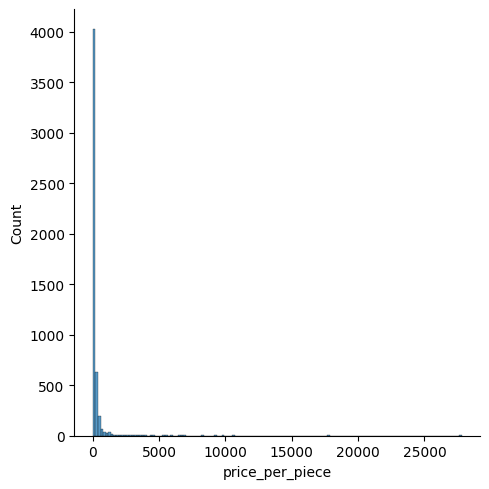

In [121]:
import seaborn as sns
# Visualization of price distribution
sns.displot(df, x = 'price_per_piece')

Because the distribution is skewed, meaning that the frequency of low/mid price product is significantly higher than high price product. This means that the price has to be transformed into log price so that this attribute does not dominate other attribute.

In [122]:
# Data Normalization 
# To ensure all feature equally contribute to the analysis, we need to normalize the data. 

from sklearn import preprocessing

# Conversion of capacity unit of kg and l into g and ml respectively.
units = ['l', 'kg']
convert = ['ml', 'g']

unit_conversion_map = {'l': 'ml', 'kg': 'g'}
df['capacity'] = pd.to_numeric(df['capacity'], errors='coerce')

for unit, target in unit_conversion_map.items():
    mask = df['capacity_unit'].eq(unit)
    df.loc[mask, 'capacity'] = df.loc[mask, 'capacity'] * 1000
    df.loc[mask, 'capacity_unit'] = target

# Convert oz to ml
oz_mask = df['capacity_unit'].eq('oz')
df.loc[oz_mask, 'capacity'] = df.loc[oz_mask, 'capacity'] * 29.5735
df.loc[oz_mask, 'capacity_unit'] = 'ml'

# Convert gallon to ml 
gal_mask = df['capacity_unit'].eq('gal')
df.loc[gal_mask, 'capacity'] = df.loc[gal_mask, 'capacity'] * 3785.41
df.loc[gal_mask, 'capacity_unit'] = 'ml'

# Standardization of capacity unit into lb into g   
lb_mask = df['capacity_unit'].eq('lb')
df.loc[lb_mask, 'capacity'] = df.loc[lb_mask, 'capacity'] * 453.592
df.loc[lb_mask, 'capacity_unit'] = 'g'

# Standardization of capacity unit into m into cm   
cm_mask = df['capacity_unit'].eq('m')
df.loc[cm_mask, 'capacity'] = df.loc[cm_mask, 'capacity'] * 100
df.loc[cm_mask, 'capacity_unit'] = 'cm'

# Categorization of capacity unit into volume, weight, and count.
unit_categorization_map = {'ml': 'volume', 'cc': 'volume', 'g': 'weight', 'pcs': 'count', 'pc': 'count', 'pack': 'count', 'set': 'count', 'bo': 'count', 'roll': 'count', 'pair': 'count', 'card': 'count', 'cm': 'length', 'bag': 'count'}
for unit, category in unit_categorization_map.items():
    mask = df['capacity_unit'].eq(unit)
    df.loc[mask, 'capacity_category'] = category

# Shelf life conversion unit
df['shelf_life_unit'] = df['shelf_life'].astype(str).str.extract(r"(\D+)", expand=False).str.strip().str.lower()
df['shelf_life'] = df['shelf_life'].replace(r'(\D+)$', '', regex=True)
df['shelf_life'] = pd.to_numeric(df['shelf_life'], errors='coerce')
shelf_life_mask = df['shelf_life'].gt(999)
df.loc[shelf_life_mask, 'shelf_life'] = 999
df['shelf_life'] = df['shelf_life'].fillna(999)

# Convert days into month by dividing the shelf life by 30
month_mask = df['shelf_life_unit'].eq('天')
df.loc[month_mask, 'shelf_life'] = df.loc[month_mask, 'shelf_life'] / 30
df.loc[month_mask, 'shelf_life_unit'] = df.loc[month_mask, 'shelf_life_unit'].replace('天', '月', regex=True)

# Convert year into month by multiplying the shelf life by 12
year_mask = df['shelf_life_unit'].eq('年')
df.loc[year_mask, 'shelf_life'] = df.loc[year_mask, 'shelf_life'] * 12  
df.loc[year_mask, 'shelf_life_unit'] = df.loc[year_mask, 'shelf_life_unit'].replace('年', '月', regex=True)

# Normalization of numeric data
# price log transformation before normalization to handle the skewness of the price distribution
log = df[['price_per_piece', 'original_price_per_piece']]
for col in log:
    df['log_' + col] = np.log1p(df[col])

min_max_scaler = preprocessing.MinMaxScaler()
cols = ['shelf_life', 'log_price_per_piece', 'log_original_price_per_piece', 'estimation_discount']

scaler = preprocessing.MinMaxScaler()
df[[c + '_normalized' for c in cols]] = scaler.fit_transform(df[cols])
df.head()

,title,category,price,brand,specification,query,original_price,original_price_checked,capacity,shelf_life,...,original_price_per_piece,estimation_discount,capacity_category,shelf_life_unit,log_price_per_piece,log_original_price_per_piece,shelf_life_normalized,log_price_per_piece_normalized,log_original_price_per_piece_normalized,estimation_discount_normalized
0,可口可樂纖維+600ml,飲料零食,120,CocaCola 可口可樂,規格：600ml毫升x1x4bottle瓶,可口可樂Zero 600ml,0,1,600.0,9.0,...,0.000000,0.000000,volume,月,3.433987,0.000000,0.000737,0.288437,0.000000,0.000000
1,可口可樂2L,飲料零食,230,CocaCola 可口可樂,規格：2000ml毫升x1x6bottle瓶,可口可樂2L,296,1,2000.0,9.0,...,49.333333,22.297297,volume,月,3.672072,3.918668,0.000737,0.313355,0.420490,0.337569
2,百事可樂330ml,飲料零食,77,百事可樂,規格：330ml毫升x1x6bottle瓶,百事可樂330ml,90,1,330.0,12.0,...,15.000000,14.444444,volume,月,2.627081,2.772589,0.000987,0.203986,0.297511,0.218681
3,百事可樂2L,飲料零食,36,百事可樂,規格：2000ml毫升x1x1bottle瓶,百事可樂2L,52,1,2000.0,12.0,...,52.000000,30.769231,volume,月,3.610918,3.970292,0.000987,0.306954,0.426030,0.465829
4,可口可樂330ml,飲料零食,83,CocaCola 可口可樂,規格：330ml毫升x1x6bottle瓶,可口可樂330ml,95,1,330.0,12.0,...,15.833333,12.631579,volume,月,2.696877,2.823361,0.000987,0.211291,0.302959,0.191235


In [123]:
save_path = "D:/ITB/Thesis/Preprocessing/preprocessed_final.csv"
df.to_csv(save_path, index=False, encoding="utf-8-sig", sep=";", decimal=",")

In [ ]:
# Filter based on business category capacity_category

#飲料零食
df_飲料零食_volume = df[(df.category == '飲料零食') & (df.capacity_category == 'volume')]
df_飲料零食_weight = df[(df.category == '飲料零食') & (df.capacity_category == 'weight')]
df_飲料零食_count = df[(df.category == '飲料零食') & (df.capacity_category == 'count')]

df_飲料零食_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_飲料零食_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_飲料零食_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_count.csv", index=False, encoding="utf-8-sig", sep=";" )

#飲料零食
df_傢俱寢飾_count = df[(df.category == '傢俱寢飾') & (df.capacity_category == 'count')]
df_傢俱寢飾_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_傢俱寢飾_count.csv", index=False, encoding="utf-8-sig", sep=";" )

#大家都買這些
df_大家都買這些_weight = df[(df.category == '大家都買這些') & (df.capacity_category == 'weight')]
df_大家都買這些_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_大家都買這些_weight.csv", index=False, encoding="utf-8-sig", sep=";" )

#嬰童保健
df_嬰童保健_volume = df[(df.category == '嬰童保健') & (df.capacity_category == 'volume')]
df_嬰童保健_weight = df[(df.category == '嬰童保健') & (df.capacity_category == 'weight')]
df_嬰童保健_count = df[(df.category == '嬰童保健') & (df.capacity_category == 'count')]

df_嬰童保健_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_嬰童保健_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_嬰童保健_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_count.csv", index=False, encoding="utf-8-sig", sep=";" )

#日用生活
df_日用生活_volume = df[(df.category == '日用生活') & (df.capacity_category == 'volume')]
df_日用生活_weight = df[(df.category == '日用生活') & (df.capacity_category == 'weight')]
df_日用生活_count = df[(df.category == '日用生活') & (df.capacity_category == 'count')]
df_日用生活_length = df[(df.category == '日用生活') & (df.capacity_category == 'length')]

df_嬰童保健_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_嬰童保健_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_嬰童保健_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_count.csv", index=False, encoding="utf-8-sig", sep=";" )

#日用生活
df_日用生活_volume = df[(df.category == '日用生活') & (df.capacity_category == 'volume')]
df_日用生活_weight = df[(df.category == '日用生活') & (df.capacity_category == 'weight')]
df_日用生活_count = df[(df.category == '日用生活') & (df.capacity_category == 'count')]
df_日用生活_length = df[(df.category == '日用生活') & (df.capacity_category == 'length')]

df_日用生活_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_日用生活_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_日用生活_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_日用生活_length.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_length.csv", index=False, encoding="utf-8-sig", sep=";" )

#服飾鞋包
df_服飾鞋包_count = df[(df.category == '服飾鞋包') & (df.capacity_category == 'count')]
df_服飾鞋包_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_服飾鞋包_count.csv", index=False, encoding="utf-8-sig", sep=";" )

# 熱門3C
df_熱門3C_count = df[(df.category == '熱門3C') & (df.capacity_category == 'count')]
df_熱門3C_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_熱門3C_count.csv", index=False, encoding="utf-8-sig", sep=";" )

#生活家電
df_生活家電_count = df[(df.category == '生活家電') & (df.capacity_category == 'count')]
df_生活家電_volume = df[(df.category == '生活家電') & (df.capacity_category == 'volume')]

df_生活家電_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_生活家電_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_生活家電_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_生活家電_volume.csv", index=False, encoding="utf-8-sig", sep=";" )

#生鮮冷凍
df_生鮮冷凍_count = df[(df.category == '生鮮冷凍') & (df.capacity_category == 'count')]
df_生鮮冷凍_volume = df[(df.category == '生鮮冷凍') & (df.capacity_category == 'volume')]
df_生鮮冷凍_weight = df[(df.category == '生鮮冷凍') & (df.capacity_category == 'weight')]

df_生鮮冷凍_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_生鮮冷凍_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_生鮮冷凍_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_weight.csv", index=False, encoding="utf-8-sig", sep=";" )

#米油沖泡
df_米油沖泡_count = df[(df.category == '米油沖泡') & (df.capacity_category == 'count')]
df_米油沖泡_weight = df[(df.category == '米油沖泡') & (df.capacity_category == 'count')]
df_米油沖泡_volume = df[(df.category == '米油沖泡') & (df.capacity_category == 'count')]

df_米油沖泡_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_米油沖泡_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_米油沖泡_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_volume.csv", index=False, encoding="utf-8-sig", sep=";" )

#美妝個清
df_美妝個清_volume = df[(df.category == '美妝個清') & (df.capacity_category == 'volume')]
df_美妝個清_weight = df[(df.category == '美妝個清') & (df.capacity_category == 'weight')]
df_美妝個清_count = df[(df.category == '美妝個清') & (df.capacity_category == 'count')]
df_美妝個清_length = df[(df.category == '美妝個清') & (df.capacity_category == 'length')]

df_美妝個清_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_美妝個清_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_weight.csv", index=False, encoding="utf-8-sig", sep=";" )
df_美妝個清_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_美妝個清_length.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_length.csv", index=False, encoding="utf-8-sig", sep=";" )

#飲料零食
df_飲料零食_count = df[(df.category == '飲料零食') & (df.capacity_category == 'count')]
df_飲料零食_volume = df[(df.category == '飲料零食') & (df.capacity_category == 'volume')]
df_飲料零食_weight = df[(df.category == '飲料零食') & (df.capacity_category == 'weight')]

df_飲料零食_count.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_count.csv", index=False, encoding="utf-8-sig", sep=";" )
df_飲料零食_volume.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_volume.csv", index=False, encoding="utf-8-sig", sep=";" )
df_飲料零食_weight.to_csv("D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_weight.csv", index=False, encoding="utf-8-sig", sep=";" )


In [66]:
# Standardization after filtering the data based on business category and capacity category

path_file_filter = ['D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_volume.csv', 
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_weight.csv', 
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_傢俱寢飾_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_大家都買這些_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_length.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_服飾鞋包_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_熱門3C_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_生活家電_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_生活家電_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_生鮮冷凍_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_米油沖泡_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_volume.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_weight.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_count.csv',
                    'D:/ITB/Thesis/Preprocessing/Filtered Data/df_美妝個清_length.csv',
                    ] 

for path in path_file_filter:
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig", thousands='.')
    scaler = preprocessing.MinMaxScaler()
    df[['capacity_normalized']] = scaler.fit_transform(df[['capacity']])
    df.to_csv(path, index=False, encoding="utf-8-sig", sep=";")
    print(path, df.shape)

D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_volume.csv (442, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_weight.csv (752, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_飲料零食_count.csv (11, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_傢俱寢飾_count.csv (60, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_大家都買這些_weight.csv (2, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_volume.csv (29, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_weight.csv (24, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_嬰童保健_count.csv (100, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_volume.csv (190, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_weight.csv (296, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_count.csv (441, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_日用生活_length.csv (4, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_服飾鞋包_count.csv (23, 29)
D:/ITB/Thesis/Preprocessing/Filtered Data/df_熱門3C_count.csv (4, 29)
D:/ITB/Thesis/Preproc